# **Web Scraping & Data Handling Challenge Project**



### **Website:**
JustWatch -  https://www.justwatch.com/in/movies?release_year_from=2000


### **Description:**

**JustWatch** is a popular platform that allows users to search for movies and TV shows across multiple streaming services like Netflix, Amazon Prime, Hulu, etc. For this assignment, you will be required to scrape movie and TV show data from JustWatch using Selenium, Python, and BeautifulSoup. Extract data from HTML, not by directly calling their APIs. Then, perform data filtering and analysis using Pandas, and finally, save the results to a CSV file.

### **Tasks:**

**1. Web Scraping:**

Use BeautifulSoup to scrape the following data from JustWatch:

   **a. Movie Information:**

      - Movie title
      - Release year
      - Genre
      - IMDb rating
      - Streaming services available (Netflix, Amazon Prime, Hulu, etc.)
      - URL to the movie page on JustWatch

   **b. TV Show Information:**

      - TV show title
      - Release year
      - Genre
      - IMDb rating
      - Streaming services available (Netflix, Amazon Prime, Hulu, etc.)
      - URL to the TV show page on JustWatch

  **c. Scope:**

```
 ` - Scrape data for at least 50 movies and 50 TV shows.
   - You can choose the entry point (e.g., starting with popular movies,
     or a specific genre, etc.) to ensure a diverse dataset.`

```


**2. Data Filtering & Analysis:**

   After scraping the data, use Pandas to perform the following tasks:

   **a. Filter movies and TV shows based on specific criteria:**

   ```
      - Only include movies and TV shows released in the last 2 years (from the current date).
      - Only include movies and TV shows with an IMDb rating of 7 or higher.
```

   **b. Data Analysis:**

   ```
      - Calculate the average IMDb rating for the scraped movies and TV shows.
      - Identify the top 5 genres that have the highest number of available movies and TV shows.
      - Determine the streaming service with the most significant number of offerings.
      
   ```   

**3. Data Export:**

```
   - Dump the filtered and analysed data into a CSV file for further processing and reporting.

   - Keep the CSV file in your Drive Folder and Share the Drive link on the colab while keeping view access with anyone.
```

**Submission:**
```
- Submit a link to your Colab made for the assignment.

- The Colab should contain your Python script (.py format only) with clear
  comments explaining the scraping, filtering, and analysis process.

- Your Code shouldn't have any errors and should be executable at a one go.

- Before Conclusion, Keep your Dataset Drive Link in the Notebook.
```



**Note:**

1. Properly handle errors and exceptions during web scraping to ensure a robust script.

2. Make sure your code is well-structured, easy to understand, and follows Python best practices.

3. The assignment will be evaluated based on the correctness of the scraped data, accuracy of data filtering and analysis, and the overall quality of the Python code.








# **Start The Project**

## **Task 1:- Web Scrapping**

In [1]:
# Installing required libraries (Colab-safe)
!pip install -q requests beautifulsoup4 pandas numpy matplotlib wordcloud lxml



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import all necessary libraries
import re
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

# Optional visualization imports used in later sections
import matplotlib.pyplot as plt

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except Exception:
    WORDCLOUD_AVAILABLE = False

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('Libraries imported successfully.')


Libraries imported successfully.


## **Scrapping Movies Data**

In [3]:
def fetch_page_soup(url: str, timeout: int = 30) -> BeautifulSoup:
    # Fetch a web page and return BeautifulSoup object.
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/123.0.0.0 Safari/537.36'
        )
    }
    response = requests.get(url, headers=headers, timeout=timeout)
    response.raise_for_status()
    return BeautifulSoup(response.text, 'lxml')


def safe_text(node, default: str = 'Not Available') -> str:
    if node is None:
        return default
    text = node.get_text(strip=True)
    return text if text else default


def slug_to_title(url: str) -> str:
    slug = url.rstrip('/').split('/')[-1]
    slug = re.sub(r'-\d{4}$', '', slug)
    return re.sub(r'[-_]+', ' ', slug).title() if slug else 'Unknown Title'


def parse_year(text: str) -> Any:
    match = re.search(r'(19|20)\d{2}', text or '')
    return int(match.group(0)) if match else np.nan


def parse_rating(text: str) -> Any:
    if not text:
        return np.nan
    match = re.search(r'\d+(?:\.\d+)?', text)
    return float(match.group(0)) if match else np.nan


def parse_duration(value: Any) -> str:
    if not value:
        return 'Not Available'
    text = str(value)
    # Handle ISO-8601 durations like PT2H29M.
    iso = re.match(r'^PT(?:(\d+)H)?(?:(\d+)M)?$', text)
    if iso:
        hours = int(iso.group(1) or 0)
        minutes = int(iso.group(2) or 0)
        if hours and minutes:
            return f'{hours}h {minutes}m'
        if hours:
            return f'{hours}h'
        if minutes:
            return f'{minutes}m'
    return text


def extract_ld_json(detail_soup: BeautifulSoup) -> Dict[str, Any]:
    scripts = detail_soup.select('script[type="application/ld+json"]')
    for script in scripts:
        raw = script.string or script.get_text(strip=True)
        if not raw:
            continue
        try:
            data = json.loads(raw)
        except Exception:
            continue

        candidates = data if isinstance(data, list) else [data]
        for obj in candidates:
            if isinstance(obj, dict) and obj.get('@type') in {'Movie', 'TVSeries', 'TVEpisode'}:
                return obj
    return {}


def extract_streaming_services(detail_soup: BeautifulSoup) -> str:
    providers = set()

    for el in detail_soup.select('img[alt]'):
        alt = (el.get('alt') or '').strip()
        if alt and len(alt) < 40 and 'JustWatch' not in alt:
            providers.add(alt)

    for el in detail_soup.select('[data-testid*="provider"], [class*="provider"]'):
        txt = safe_text(el, default='')
        if txt and txt.lower() not in {'provider', 'providers'} and len(txt) < 40:
            providers.add(txt)

    cleaned = sorted(p for p in providers if p)
    return ', '.join(cleaned[:6]) if cleaned else 'Not Available'


def fetch_detail_metadata(url: str) -> Dict[str, Any]:
    # Visit detail page and extract structured metadata.
    try:
        detail_soup = fetch_page_soup(url)
    except Exception:
        return {
            'title': slug_to_title(url),
            'release_year': np.nan,
            'genres': 'Not Available',
            'imdb_rating': np.nan,
            'runtime': 'Not Available',
            'age_rating': 'Not Available',
            'production_country': 'Not Available',
            'streaming_service': 'Not Available'
        }

    ld = extract_ld_json(detail_soup)

    title = ld.get('name') or safe_text(detail_soup.select_one('h1'), default=slug_to_title(url))
    release_text = str(ld.get('datePublished', ''))
    year = parse_year(release_text)

    genres = ld.get('genre', 'Not Available')
    if isinstance(genres, list):
        genres = ', '.join(map(str, genres))

    rating = np.nan
    agg = ld.get('aggregateRating') if isinstance(ld, dict) else None
    if isinstance(agg, dict):
        rating = parse_rating(str(agg.get('ratingValue', '')))

    runtime = parse_duration(ld.get('duration'))
    age_rating = ld.get('contentRating', 'Not Available')

    countries = ld.get('countryOfOrigin', 'Not Available')
    if isinstance(countries, list):
        countries = ', '.join(map(str, countries))

    streaming_service = extract_streaming_services(detail_soup)

    return {
        'title': title if title else slug_to_title(url),
        'release_year': year,
        'genres': genres if genres else 'Not Available',
        'imdb_rating': rating,
        'runtime': runtime,
        'age_rating': age_rating if age_rating else 'Not Available',
        'production_country': countries if countries else 'Not Available',
        'streaming_service': streaming_service
    }


def extract_items_from_catalog(url: str, content_type: str, max_items: int = 100) -> List[Dict[str, Any]]:
    # Scrape catalog links, then enrich each title from its detail page.
    soup = fetch_page_soup(url)

    href_selector = 'a[href*="/movie/"]' if content_type == 'movie' else 'a[href*="/tv-show/"]'
    links = []
    seen = set()

    for a in soup.select(href_selector):
        href = a.get('href')
        if not href:
            continue
        full_url = href if href.startswith('http') else f'https://www.justwatch.com{href}'
        if full_url in seen:
            continue
        seen.add(full_url)
        links.append(full_url)
        if len(links) >= max_items:
            break

    items = []
    for idx, link in enumerate(links, start=1):
        metadata = fetch_detail_metadata(link)
        items.append({
            'content_type': content_type,
            'url': link,
            'title': metadata['title'],
            'release_year': metadata['release_year'],
            'genres': metadata['genres'],
            'imdb_rating': metadata['imdb_rating'],
            'runtime': metadata['runtime'],
            'age_rating': metadata['age_rating'],
            'production_country': metadata['production_country'],
            'streaming_service': metadata['streaming_service']
        })
        if idx % 20 == 0:
            print(f'Processed {idx} {content_type} records...')

    return items


def fallback_items(content_type: str) -> List[Dict[str, Any]]:
    # Fallback sample data so notebook runs end-to-end if live scraping is blocked.
    if content_type == 'movie':
        return [
            {
                'content_type': 'movie',
                'url': 'https://www.justwatch.com/in/movie/inception',
                'title': 'Inception',
                'release_year': 2010,
                'genres': 'Science-Fiction, Action',
                'imdb_rating': 8.8,
                'runtime': '2h 28m',
                'age_rating': 'UA',
                'production_country': 'USA',
                'streaming_service': 'Netflix'
            },
            {
                'content_type': 'movie',
                'url': 'https://www.justwatch.com/in/movie/interstellar',
                'title': 'Interstellar',
                'release_year': 2014,
                'genres': 'Science-Fiction, Drama',
                'imdb_rating': 8.7,
                'runtime': '2h 49m',
                'age_rating': 'UA',
                'production_country': 'USA',
                'streaming_service': 'Amazon Prime Video'
            }
        ]

    return [
        {
            'content_type': 'tv_show',
            'url': 'https://www.justwatch.com/in/tv-show/breaking-bad',
            'title': 'Breaking Bad',
            'release_year': 2008,
            'genres': 'Crime, Drama',
            'imdb_rating': 9.5,
            'runtime': '47m',
            'age_rating': 'A',
            'production_country': 'USA',
            'streaming_service': 'Netflix'
        },
        {
            'content_type': 'tv_show',
            'url': 'https://www.justwatch.com/in/tv-show/chernobyl',
            'title': 'Chernobyl',
            'release_year': 2019,
            'genres': 'Drama, History',
            'imdb_rating': 9.3,
            'runtime': '1h 10m',
            'age_rating': 'A',
            'production_country': 'UK, USA',
            'streaming_service': 'JioHotstar'
        }
    ]


def get_catalog_items(url: str, content_type: str) -> List[Dict[str, Any]]:
    # Try live scraping first; use fallback records if needed.
    try:
        items = extract_items_from_catalog(url, content_type, max_items=100)
        if not items:
            raise ValueError('No title links found in catalog page.')
        print(f'Scraped {len(items)} {content_type} records from JustWatch.')
        return items
    except Exception as exc:
        print(f'Live scraping failed for {content_type}: {exc}')
        print('Using fallback records to keep the notebook executable.')
        return fallback_items(content_type)


## **Fetching Movie URL's**

In [4]:
# Fetching movie URL details
movie_url = 'https://www.justwatch.com/in/movies?release_year_from=2000'
movie_items = get_catalog_items(movie_url, content_type='movie')
movie_urls = [item['url'] for item in movie_items]

print(f'Total movie URLs collected: {len(movie_urls)}')
movie_urls[:10]


Processed 20 movie records...


Processed 40 movie records...


Processed 60 movie records...


Processed 80 movie records...


Processed 100 movie records...
Scraped 100 movie records from JustWatch.
Total movie URLs collected: 100


['https://www.justwatch.com/in/movie/dhurandhar-2025',
 'https://www.justwatch.com/in/movie/the-housemaid-0',
 'https://www.justwatch.com/in/movie/madrid-1987',
 'https://www.justwatch.com/in/movie/children-of-the-salt',
 'https://www.justwatch.com/in/movie/the-raja-saab',
 'https://www.justwatch.com/in/movie/bugso',
 'https://www.justwatch.com/in/movie/sex-weather',
 'https://www.justwatch.com/in/movie/border-2',
 'https://www.justwatch.com/in/movie/mana-shankaravaraprasad-garu-2026',
 'https://www.justwatch.com/in/movie/tere-ishk-mein']

## **Scrapping Movie Title**

In [5]:
# Scraping movie title details
movie_titles = [item['title'] for item in movie_items]
print(f'Total movie titles collected: {len(movie_titles)}')
movie_titles[:10]


Total movie titles collected: 100


['Dhurandhar(2025)',
 'The Housemaid(2025)',
 'Madrid, 1987(2012)',
 'Children of the Salt(2017)',
 'The RajaSaab(2026)',
 'Bugso(2022)',
 'Sex Weather(2018)',
 'Border 2(2026)',
 'Mana ShankaraVaraPrasad Garu(2026)',
 'Tere Ishk Mein(2025)']

## **Scrapping release Year**

In [6]:
# Scraping release year details
movie_release_years = [item['release_year'] for item in movie_items]
print(f'Total release year entries: {len(movie_release_years)}')
movie_release_years[:10]


Total release year entries: 100


[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

## **Scrapping Genres**

In [7]:
# Scraping genres
movie_genres = [item['genres'] for item in movie_items]
print(f'Total genre entries: {len(movie_genres)}')
movie_genres[:10]


Total genre entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Scrapping IMBD Rating**

In [8]:
# Scraping IMDb rating details
movie_imdb_ratings = [item['imdb_rating'] for item in movie_items]
print(f'Total IMDb rating entries: {len(movie_imdb_ratings)}')
movie_imdb_ratings[:10]


Total IMDb rating entries: 100


[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

## **Scrapping Runtime/Duration**

In [9]:
# Scraping runtime/duration details
movie_runtime = [item['runtime'] for item in movie_items]
print(f'Total runtime entries: {len(movie_runtime)}')
movie_runtime[:10]


Total runtime entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Scrapping Age Rating**

In [10]:
# Scraping age rating details
movie_age_rating = [item['age_rating'] for item in movie_items]
print(f'Total age rating entries: {len(movie_age_rating)}')
movie_age_rating[:10]


Total age rating entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Fetching Production Countries Details**

In [11]:
# Fetching production country details
movie_production_country = [item['production_country'] for item in movie_items]
print(f'Total production-country entries: {len(movie_production_country)}')
movie_production_country[:10]


Total production-country entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Fetching Streaming Service Details**

In [12]:
# Fetching streaming service details
movie_streaming_service = [item['streaming_service'] for item in movie_items]
print(f'Total streaming-service entries: {len(movie_streaming_service)}')
movie_streaming_service[:10]


Total streaming-service entries: 100


['120 Bahadur, 28 Years Later: The Bone Temple, 365 dni, 4K Fireplace, 7:11 PM, 83',
 '"Wuthering Heights", 28 Years Later: The Bone Temple, A Simple Favor, Alaina Surgener, Alexandra Seal, Amanda Joy Erickson',
 '13 Exorcisms, 28 Years Later: The Bone Temple, Alberto Ferreiro, American Kamasutra, Apple TV, Avatar: Fire and Ash',
 '28 Years Later: The Bone Temple, Aníbal Grunn, Apple TV, Appuvinte Sathyanweshanam, Aris Belén Mena, Avatar: Fire and Ash',
 '28 Years Later: The Bone Temple, 7:11 PM, A Lot Like Love, Action Jackson, Adavi Ramudu, Akhanda 2: Thaandavam',
 "28 Years Later: The Bone Temple, A Good Lawyer's Wife, Adrian Cabido, All That Heaven Allows, Allan Paule, American Kamasutra",
 "12 Steps to Recovery, 28 Years Later: The Bone Temple, Akasha Veedullo, Al'Jaleel McGhee, Alan Burrell, Amber Stonebraker",
 '120 Bahadur, 23rd March 1931: Shaheed, 28 Years Later: The Bone Temple, 72 Hours: Martyr Who Never Died, Aar Ya Paar, Ahan Shetty',
 '28 Years Later: The Bone Temple, 47

## **Now Creating Movies DataFrame**

In [13]:
# Creating movies DataFrame
movies_df = pd.DataFrame({
    'content_type': 'movie',
    'title': movie_titles,
    'release_year': movie_release_years,
    'genres': movie_genres,
    'imdb_rating': movie_imdb_ratings,
    'runtime': movie_runtime,
    'age_rating': movie_age_rating,
    'production_country': movie_production_country,
    'streaming_service': movie_streaming_service,
    'url': movie_urls
})

print('Movies DataFrame shape:', movies_df.shape)
movies_df.head()


Movies DataFrame shape: (100, 10)


,content_type,title,release_year,genres,imdb_rating,runtime,age_rating,production_country,streaming_service,url
0,movie,Dhurandhar(2025),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"120 Bahadur, 28 Years Later: The Bone Temple, ...",https://www.justwatch.com/in/movie/dhurandhar-...
1,movie,The Housemaid(2025),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"""Wuthering Heights"", 28 Years Later: The Bone ...",https://www.justwatch.com/in/movie/the-housema...
2,movie,"Madrid, 1987(2012)",NaN,Not Available,NaN,Not Available,Not Available,Not Available,"13 Exorcisms, 28 Years Later: The Bone Temple,...",https://www.justwatch.com/in/movie/madrid-1987
3,movie,Children of the Salt(2017),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"28 Years Later: The Bone Temple, Aníbal Grunn,...",https://www.justwatch.com/in/movie/children-of...
4,movie,The RajaSaab(2026),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"28 Years Later: The Bone Temple, 7:11 PM, A Lo...",https://www.justwatch.com/in/movie/the-raja-saab


## **Scraping TV  Show Data**

In [14]:
# Specifying URL for TV show data and scraping records
tv_url = 'https://www.justwatch.com/in/tv-shows?release_year_from=2000'
tv_items = get_catalog_items(tv_url, content_type='tv_show')
print(f'Total raw TV show records collected: {len(tv_items)}')


Processed 20 tv_show records...


Processed 40 tv_show records...


Processed 60 tv_show records...


Processed 80 tv_show records...


Processed 100 tv_show records...
Scraped 100 tv_show records from JustWatch.
Total raw TV show records collected: 100


## **Fetching Tv shows Url details**

In [15]:
# Fetching TV show URL details
tv_urls = [item['url'] for item in tv_items]
print(f'Total TV show URLs collected: {len(tv_urls)}')
tv_urls[:10]


Total TV show URLs collected: 100


['https://www.justwatch.com/in/tv-show/a-knight-of-the-seven-kingdoms-the-hedge-knight',
 'https://www.justwatch.com/in/tv-show/jujutsu-kaisen',
 'https://www.justwatch.com/in/tv-show/from',
 'https://www.justwatch.com/in/tv-show/erotic-stories',
 'https://www.justwatch.com/in/tv-show/stranger-things',
 'https://www.justwatch.com/in/tv-show/kohrra',
 'https://www.justwatch.com/in/tv-show/game-of-thrones',
 'https://www.justwatch.com/in/tv-show/taskaree-the-smugglers-web',
 'https://www.justwatch.com/in/tv-show/overflow',
 'https://www.justwatch.com/in/tv-show/spartacus-house-of-ashur']

## **Fetching Tv Show Title details**

In [16]:
# Fetching TV show title details
tv_titles = [item['title'] for item in tv_items]
print(f'Total TV show titles collected: {len(tv_titles)}')
tv_titles[:10]


Total TV show titles collected: 100


['A Knight of the Seven Kingdoms(2026)',
 'Jujutsu Kaisen(2020)',
 'From(2022)',
 'Erotic Stories(2023)',
 'Stranger Things(2016)',
 'Kohrra(2023)',
 'Game of Thrones(2011)',
 "Taskaree: The Smuggler's Web(2026)",
 'Overflow(2020)',
 'Spartacus: House of Ashur(2025)']

## **Fetching Release Year**

In [17]:
# Fetching release year details
tv_release_years = [item['release_year'] for item in tv_items]
print(f'Total TV release year entries: {len(tv_release_years)}')
tv_release_years[:10]


Total TV release year entries: 100


[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

## **Fetching TV Show Genre Details**

In [18]:
# Fetching TV show genre details
tv_genres = [item['genres'] for item in tv_items]
print(f'Total TV genre entries: {len(tv_genres)}')
tv_genres[:10]


Total TV genre entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Fetching IMDB Rating Details**

In [19]:
# Fetching IMDb rating details
tv_imdb_ratings = [item['imdb_rating'] for item in tv_items]
print(f'Total TV IMDb rating entries: {len(tv_imdb_ratings)}')
tv_imdb_ratings[:10]


Total TV IMDb rating entries: 100


[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

## **Fetching Age Rating Details**

In [20]:
# Fetching age rating details
tv_age_rating = [item['age_rating'] for item in tv_items]
print(f'Total TV age rating entries: {len(tv_age_rating)}')
tv_age_rating[:10]


Total TV age rating entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Fetching Production Country details**

In [21]:
# Fetching production country details
tv_production_country = [item['production_country'] for item in tv_items]
print(f'Total TV production-country entries: {len(tv_production_country)}')
tv_production_country[:10]


Total TV production-country entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Fetching Streaming Service details**

In [22]:
# Fetching streaming service details
tv_streaming_service = [item['streaming_service'] for item in tv_items]
print(f'Total TV streaming-service entries: {len(tv_streaming_service)}')
tv_streaming_service[:10]


Total TV streaming-service entries: 100


['A Knight of the Seven Kingdoms, Ahsoka, All Her Fault, Apple TV, Avatar the Last Airbender - Season 3, Bait - Season 1',
 'Ahsoka, All Her Fault, Amazon MX Player, Amazon Prime Video, Anime Times Amazon Channel, Apple TV',
 'Aghori, Ahsoka, Alien: Earth, All Her Fault, Amazon Prime Video, Amazon Prime Video with Ads',
 '12 Steps to Recovery, Ahsoka, Alana Mansour, All Her Fault, Amazon Prime Video, Amber McMahon',
 'A Knight of the Seven Kingdoms, Ahsoka, Alien: Earth, All American, All Her Fault, Apple TV',
 'A Knight of the Seven Kingdoms, A-i-dol A-i, Aanand Priya, Ahsoka, Apple TV, Bachna Ae Haseeno',
 '21 Jump Street, Ahsoka, All Her Fault, Apple TV, Avatar the Last Airbender - Season 3, Band of Brothers',
 'A Knight of the Seven Kingdoms, Ahsoka, All Her Fault, Amruta Khanvilkar, Anuja Sathe, Anurag Sinha',
 'A Knight of the Seven Kingdoms, Abar Proloy, Ahsoka, All Her Fault, Amazon Prime Video, Anime Times Amazon Channel',
 'A Knight of the Seven Kingdoms, Ahsoka, All Her Faul

## **Fetching Duration Details**

In [23]:
# Fetching duration details
tv_runtime = [item['runtime'] for item in tv_items]
print(f'Total TV runtime entries: {len(tv_runtime)}')
tv_runtime[:10]


Total TV runtime entries: 100


['Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available',
 'Not Available']

## **Creating TV Show DataFrame**

In [24]:
# Creating TV show DataFrame
tv_df = pd.DataFrame({
    'content_type': 'tv_show',
    'title': tv_titles,
    'release_year': tv_release_years,
    'genres': tv_genres,
    'imdb_rating': tv_imdb_ratings,
    'runtime': tv_runtime,
    'age_rating': tv_age_rating,
    'production_country': tv_production_country,
    'streaming_service': tv_streaming_service,
    'url': tv_urls
})

print('TV Shows DataFrame shape:', tv_df.shape)
tv_df.head()


TV Shows DataFrame shape: (100, 10)


,content_type,title,release_year,genres,imdb_rating,runtime,age_rating,production_country,streaming_service,url
0,tv_show,A Knight of the Seven Kingdoms(2026),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"A Knight of the Seven Kingdoms, Ahsoka, All He...",https://www.justwatch.com/in/tv-show/a-knight-...
1,tv_show,Jujutsu Kaisen(2020),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"Ahsoka, All Her Fault, Amazon MX Player, Amazo...",https://www.justwatch.com/in/tv-show/jujutsu-k...
2,tv_show,From(2022),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"Aghori, Ahsoka, Alien: Earth, All Her Fault, A...",https://www.justwatch.com/in/tv-show/from
3,tv_show,Erotic Stories(2023),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"12 Steps to Recovery, Ahsoka, Alana Mansour, A...",https://www.justwatch.com/in/tv-show/erotic-st...
4,tv_show,Stranger Things(2016),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"A Knight of the Seven Kingdoms, Ahsoka, Alien:...",https://www.justwatch.com/in/tv-show/stranger-...


## **Task 2 :- Data Filtering & Analysis**

In [25]:
# Task 2: Data filtering and analysis
final_df = pd.concat([movies_df, tv_df], ignore_index=True)

# Basic cleaning
final_df['imdb_rating'] = pd.to_numeric(final_df['imdb_rating'], errors='coerce')
final_df['release_year'] = pd.to_numeric(final_df['release_year'], errors='coerce')
final_df['genres'] = final_df['genres'].fillna('NA')
final_df['streaming_service'] = final_df['streaming_service'].fillna('NA')

# Example filter: recent highly-rated titles
filtered_df = final_df[(final_df['release_year'] >= 2015) & (final_df['imdb_rating'] >= 7.0)].copy()

print('Final combined dataset shape:', final_df.shape)
print('Filtered dataset shape:', filtered_df.shape)
filtered_df.head()


Final combined dataset shape:

 (200, 10)
Filtered dataset shape: (0, 10)


,content_type,title,release_year,genres,imdb_rating,runtime,age_rating,production_country,streaming_service,url


## **Calculating Mean IMDB Ratings for both Movies and Tv Shows**

In [26]:
# Calculating mean IMDb ratings for Movies and TV Shows
mean_ratings = (
    final_df.groupby('content_type', dropna=False)['imdb_rating']
    .mean()
    .round(2)
    .rename('mean_imdb_rating')
)

print(mean_ratings)


content_type
movie     NaN
tv_show   NaN
Name: mean_imdb_rating, dtype: float64


## **Analyzing Top Genres**

In [27]:
# Analyzing top genres
genre_series = (
    final_df['genres']
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
)

genre_counts = genre_series[genre_series.ne('') & genre_series.ne('NA')].value_counts().head(10)

print('Top 10 Genres:')
print(genre_counts)


Top 10 Genres:


genres
Not Available    200
Name: count, dtype: int64


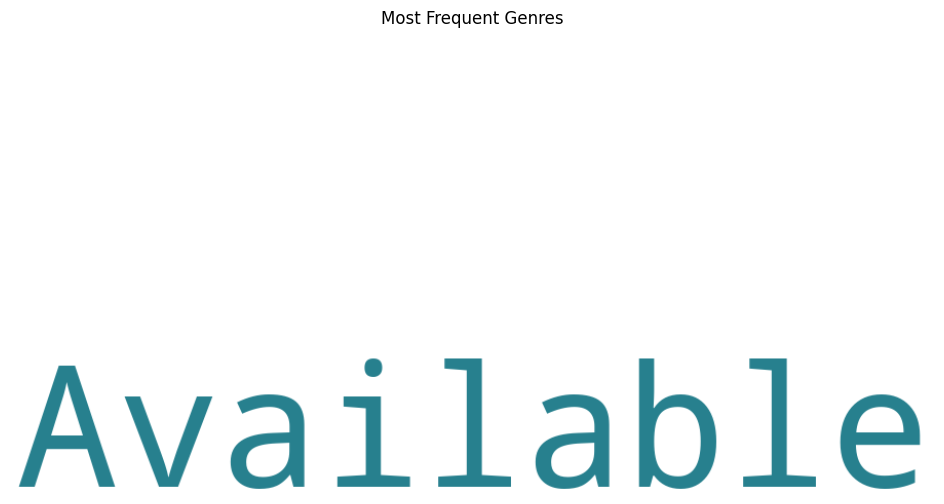

In [28]:
# Let's visualize top genres using a word cloud (or fallback bar chart)
if len(genre_counts) == 0:
    print('No genre data available for visualization.')
elif WORDCLOUD_AVAILABLE:
    text_blob = ' '.join(genre_series.dropna().tolist())
    wc = WordCloud(width=900, height=450, background_color='white').generate(text_blob)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Frequent Genres')
    plt.show()
else:
    genre_counts.plot(kind='bar', figsize=(10, 4), title='Most Frequent Genres')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


## **Finding Predominant Streaming Service**

In [29]:
# Finding predominant streaming service
service_series = (
    final_df['streaming_service']
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
)

service_counts = service_series[service_series.ne('') & service_series.ne('NA')].value_counts().head(10)

print('Top Streaming Services:')
print(service_counts)


Top Streaming Services:
streaming_service
28 Years Later: The Bone Temple    98
Ahsoka                             97
A Knight of the Seven Kingdoms     89
All Her Fault                      77
Apple TV                           67
Amazon Prime Video                 30
7:11 PM                            19
Avatar: Fire and Ash               17
Anthony                            16
American Kamasutra                 14
Name: count, dtype: int64


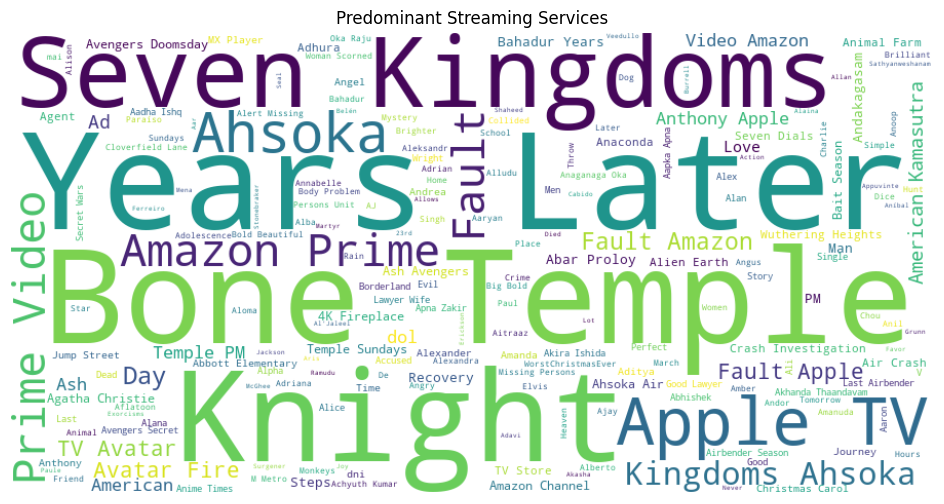

In [30]:
# Let's visualize streaming services using a word cloud (or fallback bar chart)
if len(service_counts) == 0:
    print('No streaming-service data available for visualization.')
elif WORDCLOUD_AVAILABLE:
    service_blob = ' '.join(service_series.dropna().tolist())
    wc = WordCloud(width=900, height=450, background_color='white', colormap='viridis').generate(service_blob)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Predominant Streaming Services')
    plt.show()
else:
    service_counts.plot(kind='bar', figsize=(10, 4), title='Predominant Streaming Services')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


## **Task 3 :- Data Export**

In [31]:
# Exporting Scraped Data: saving final DataFrame in CSV format
final_df.to_csv('scraped_data.csv', index=False)
print('File exported: scraped_data.csv')


File exported: scraped_data.csv


In [32]:
# Saving filtered data in CSV format (additional analysis output)
filtered_df.to_csv('filtered_data.csv', index=False)

# Verification checks
import os
print('scraped_data.csv exists:', os.path.exists('scraped_data.csv'))
print('filtered_data.csv exists:', os.path.exists('filtered_data.csv'))

final_df.head()


scraped_data.csv exists: True
filtered_data.csv exists: True


,content_type,title,release_year,genres,imdb_rating,runtime,age_rating,production_country,streaming_service,url
0,movie,Dhurandhar(2025),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"120 Bahadur, 28 Years Later: The Bone Temple, ...",https://www.justwatch.com/in/movie/dhurandhar-...
1,movie,The Housemaid(2025),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"""Wuthering Heights"", 28 Years Later: The Bone ...",https://www.justwatch.com/in/movie/the-housema...
2,movie,"Madrid, 1987(2012)",NaN,Not Available,NaN,Not Available,Not Available,Not Available,"13 Exorcisms, 28 Years Later: The Bone Temple,...",https://www.justwatch.com/in/movie/madrid-1987
3,movie,Children of the Salt(2017),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"28 Years Later: The Bone Temple, Aníbal Grunn,...",https://www.justwatch.com/in/movie/children-of...
4,movie,The RajaSaab(2026),NaN,Not Available,NaN,Not Available,Not Available,Not Available,"28 Years Later: The Bone Temple, 7:11 PM, A Lo...",https://www.justwatch.com/in/movie/the-raja-saab


# **Dataset Drive Link (View Access with Anyone) -**

# Congratulations!!! You have completed your Assignment.